In [96]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
import operator

In [97]:
generator_llm = ChatOpenAI(model='gpt-4o-mini')
evaluator_llm = ChatOpenAI(model='gpt-4o-mini')
optimizer_llm = ChatOpenAI(model='gpt-4o-mini')

In [98]:
from pydantic import BaseModel, Field

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [99]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [100]:
# state
class TweetState(TypedDict):
    topic: str 
    tweet: str
    evaluation: Literal['approved', 'needs_improvement']
    feedback: str
    iteration: int
    max_iteration: int

    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [101]:
def generate_tweet(state: TweetState):
    # prompt
    messages = [
            SystemMessage(content="You are a funny and clever Twitter/X influencer."),
            HumanMessage(content=f"""
    Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

    Rules:
    - Do NOT use question-answer format.
    - Max 280 characters.
    - Use observational humor, irony, sarcasm, or cultural references.
    - Think in meme logic, punchlines, or relatable takes.
    - Use simple, day to day english
    """)
        ]

    # send generator_llm
    response = generator_llm.invoke(messages).content

    # return response
    return {'tweet': response, 'tweet_history': [response]}

def evaluate_tweet(state: TweetState):
    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

def optimize_tweet(state: TweetState):

    messages = [
            SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
            HumanMessage(content=f"""
    Improve the tweet based on this feedback:
    "{state['feedback']}"

    Topic: "{state['topic']}"
    Original Tweet:
    {state['tweet']}

    Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
    """)
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [102]:
def route_evaluation(state: TweetState):
    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

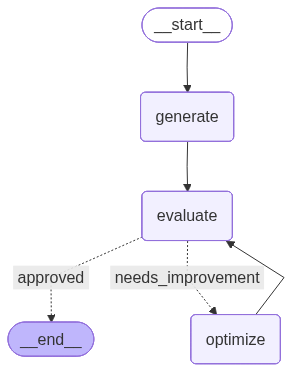

In [103]:
graph = StateGraph(TweetState)

graph.add_node('generate', generate_tweet)
graph.add_node('evaluate', evaluate_tweet)
graph.add_node('optimize', optimize_tweet)

graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')
graph.add_conditional_edges('evaluate', route_evaluation, {'approved': END, 'needs_improvement' : 'optimize'})
graph.add_edge('optimize', 'evaluate')

workflow = graph.compile()

workflow


In [104]:
initial_state = {
    'topic': 'huehuehue',
    'iteration': 1,
    'max_iteration': 5
}

workflow.invoke(initial_state)

{'topic': 'huehuehue',
 'tweet': 'When toddlers start giggling "huehuehue," you know they\'ve just turned the neighbor’s WiFi into a digital playground! 🎉🤣 Chaos has never sounded so cute! #Huehuehue',
 'evaluation': 'needs_improvement',
 'feedback': "While the tweet has a relatable premise about toddlers and WiFi, it lacks originality as it's a common theme to associate children with technology mishaps. The humor is somewhat cute but not particularly strong or innovative, failing to evoke a genuine laugh. It is fairly punchy, but the punchline doesn’t hit hard enough to stand out. The potential for virality is limited due to its somewhat generic nature. Lastly, the format is acceptable, as it's under 280 characters and does not follow a traditional joke structure.",
 'iteration': 5,
 'max_iteration': 5,
 'tweet_history': ['Just found out "huehuehue" is the universal sound for “I just pulled off a mischievous plan, but I forgot I’m not supposed to be on this WiFi.” It\'s basically the 